# Notebook 9: Compound Repeats — NW-flex vs BWA-MEM

This notebook is the compound-repeat counterpart to Notebook 7. The reader is assumed to have just been through Notebook 7; here we surface only what is **new** to the compound case and refer back to Notebook 7 for everything that carries over unchanged.

The locus now contains two adjacent repeat blocks joined by a short bridge,
$$X = A \cdot R_1^{N_1} \cdot M \cdot R_2^{N_2} \cdot B,$$
and the haplotype varies both repeat counts independently as $(\Delta_1, \Delta_2)$. The compound-specific failure mode for BWA-MEM is a *bridge-anchoring* effect: a short bridge starves the seeder of anchor sequence between blocks, and the local extender then has to choose between near-tied alignments at both block boundaries. NW-flex's multi-block EP pattern is exhaustive over the product of allowed counts, so it is correct by construction whenever the only difference is the repeat counts.

## Setup

Same imports, scoring, and runtime requirements as Notebook 7. The only addition is `build_EP_multi_STR_phase` for the two-block NW-flex configuration.

In [83]:
get_ipython().run_line_magic('load_ext', 'autoreload')
get_ipython().run_line_magic('autoreload', '2')

from dataclasses import dataclass, field
from functools import reduce
from itertools import product
from pathlib import Path
from types import SimpleNamespace
from typing import List, Optional, Tuple
import shutil

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, Patch, Rectangle

from nwflex.aligners import RefAligner
from nwflex.default import get_default_scoring
from nwflex.ep_patterns import build_EP_multi_STR_phase

from nwflex.simulation import (
    # carried over from Notebook 7
    clean_flank_window,
    tile_reads, mirror_reads, build_mirror_frame, reverse_complement,
    align_bwa, align_bwa_both_strands, align_nwflex,
    score_alignment, alignment_state, state_to_glyph, combine_states,
    parse_cigar, decode_z_bp, flank_bases_consumed,
    sweep, pivot_for_heatmap, SweepVariant,
    plot_correctness_heatmap, plot_correctness_heatmap_rows,
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [84]:
# BWA-MEM-compatible scoring (+1 / -4 / -6 / -1) — same as Notebook 7.
score_matrix, gap_open, gap_extend, a2i = get_default_scoring("bwa_mem")
sc_kw = dict(score_matrix=score_matrix, gap_open=gap_open,
             gap_extend=gap_extend, alphabet_to_index=a2i)

In [85]:
required = ("bwa", "samtools")
missing = [t for t in required if shutil.which(t) is None]
print("Missing on PATH:" if missing else "Found on PATH:", ", ".join(missing or required))

Found on PATH: bwa, samtools


In [86]:
PANEL_PATH = Path("../data/hg38_motif_sample_K100.tsv")
panel = pd.read_csv(PANEL_PATH, sep="\t")
print(f"Loaded {len(panel):,} loci from {PANEL_PATH}")

Loaded 6,900 loci from ../data/hg38_motif_sample_K100.tsv


## Simulation

Four stages as in Notebook 7: **reference → haplotype → reads → mirror**. What is new:

- The **reference** stage now builds a compound locus $(A, R_1, N_1, M, R_2, N_2, B)$ and packs the NW-flex extended reference $(3N_1, 3N_2)$ alongside it, all in one object.
- The **haplotype** stage takes a pair $(\Delta_1, \Delta_2)$ instead of a single $\Delta$.
- **Reads** and **mirror** carry over from Notebook 7; the mirror frame now reverses two zones instead of one.

The schematic below previews the compound layout: outer flanks $A, B$, the two repeat blocks $R_1^{N_1}$ and $R_2^{N_2}$, and the bridge $M$ between them. The right panel shows the mirror frame used for strand-symmetric alignment.

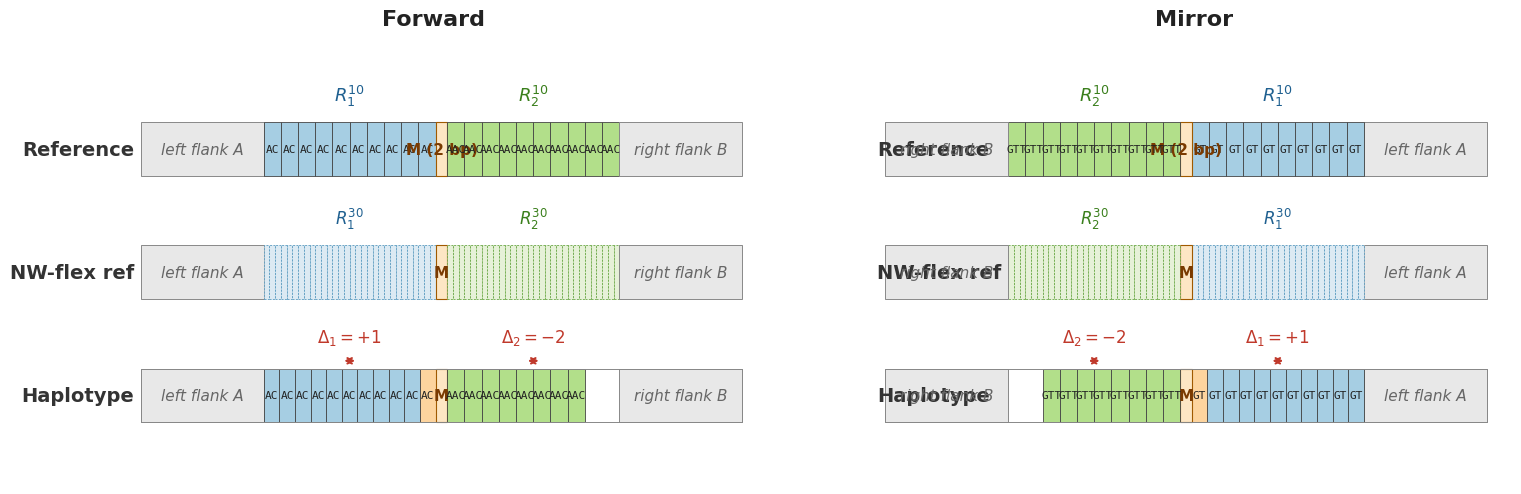

In [87]:
# Compound analogue of plot_layout_schematic: a reference row showing
# A · R1^N1 · M · R2^N2 · B, an optional NW-flex row with R1^(f·N1) and
# R2^(f·N2), and a haplotype row that compresses tiles when Δ > 0 and
# shows fewer tiles when Δ < 0. Δ1 / Δ2 brackets sit under the haplotype.
# Mirror mode flips the axis horizontally so left/right read consistently
# in rc coordinates.
def plot_compound_layout_schematic(
    *, motif1, motif2, ref_n1, ref_n2, bridge_len,
    delta1_example=0, delta2_example=0,
    nwflex_factor=3, show_nwflex=True,
    mirror=False, ax=None,
    suptitle=None, subtitle=None,
    figsize=(15.0, 5.6), fontsize=13,
):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=figsize)
    else:
        fig = ax.figure
    fig.patch.set_facecolor("white")
    ax.set_facecolor("white")

    disp1 = reverse_complement(motif1) if mirror else motif1
    disp2 = reverse_complement(motif2) if mirror else motif2

    flank_w = 7.5
    tile_w  = 1.05
    bar_h   = 0.7
    bridge_w = max(0.7, 0.35 + 0.18 * bridge_len)

    n1_hap = max(ref_n1 + delta1_example, 0)
    n2_hap = max(ref_n2 + delta2_example, 0)

    big_gap = 0.9
    y_hap = 0.4
    if show_nwflex:
        y_nwf = y_hap + bar_h + big_gap
        y_ref = y_nwf + bar_h + big_gap
    else:
        y_nwf = None
        y_ref = y_hap + bar_h + big_gap

    flank_color = "#e8e8e8"
    motif_color_1 = "#a6cee3"
    motif_color_2 = "#b2df8a"
    extra_color  = "#fdd49e"
    bridge_color = "#fde6c4"
    nwflex_color_1 = "#dceaf3"
    nwflex_color_2 = "#e6f1d8"
    nwflex_edge_1  = "#5a9bc0"
    nwflex_edge_2  = "#6aa845"
    missing_edge = "#c0392b"

    def _row_label(y, text):
        x = (flank_w * 2 + ref_n1 * tile_w + bridge_w + ref_n2 * tile_w + 0.5
             if mirror else -0.4)
        ha = "left" if mirror else "right"
        ax.text(x, y + bar_h / 2, text, ha=ha, va="center",
                fontsize=fontsize + 1, fontweight="bold", color="#333333")

    def _flank(x, y, w, label):
        ax.add_patch(Rectangle((x, y), w, bar_h, facecolor=flank_color,
                               edgecolor="#888888", linewidth=0.7))
        ax.text(x + w / 2, y + bar_h / 2, label, ha="center", va="center",
                fontsize=fontsize - 2, style="italic", color="#666666")

    def _tile(x, y, w, color, text=None, dashed=False, edge_color=None):
        kw = dict(facecolor=color, edgecolor=edge_color or "#444444",
                  linewidth=0.6)
        if dashed:
            kw["linestyle"] = (0, (2.5, 1.5))
        ax.add_patch(Rectangle((x, y), w, bar_h, **kw))
        if text and w >= 0.45:
            ax.text(x + w / 2, y + bar_h / 2, text,
                    ha="center", va="center",
                    fontsize=fontsize - 5, family="monospace",
                    color="#222222")

    def _bridge_box(x, y, w, label):
        ax.add_patch(Rectangle((x, y), w, bar_h, facecolor=bridge_color,
                               edgecolor="#a05a00", linewidth=0.8))
        ax.text(x + w / 2, y + bar_h / 2, label,
                ha="center", va="center",
                fontsize=fontsize - 2, fontweight="bold", color="#7a3a00")

    block1_panel_w = ref_n1 * tile_w
    block2_panel_w = ref_n2 * tile_w

    # --- Reference row -----------------------------------------------------
    _row_label(y_ref, "Reference")
    x0 = 0.0
    _flank(x0, y_ref, flank_w, "left flank A")
    x0 += flank_w
    for i in range(ref_n1):
        _tile(x0 + i * tile_w, y_ref, tile_w, motif_color_1, disp1)
    x0 += block1_panel_w
    _bridge_box(x0, y_ref, bridge_w, f"M ({bridge_len} bp)")
    x0 += bridge_w
    for i in range(ref_n2):
        _tile(x0 + i * tile_w, y_ref, tile_w, motif_color_2, disp2)
    x0 += block2_panel_w
    _flank(x0, y_ref, flank_w, "right flank B")
    x_end = x0 + flank_w

    label_y = y_ref + bar_h + 0.18
    ax.text(flank_w + block1_panel_w / 2, label_y,
            f"$R_1^{{{ref_n1}}}$", ha="center", va="bottom",
            fontsize=fontsize, color="#1f6090", fontweight="bold")
    ax.text(flank_w + block1_panel_w + bridge_w + block2_panel_w / 2,
            label_y,
            f"$R_2^{{{ref_n2}}}$", ha="center", va="bottom",
            fontsize=fontsize, color="#3a7f1c", fontweight="bold")

    # --- NW-flex row -------------------------------------------------------
    if show_nwflex:
        _row_label(y_nwf, "NW-flex ref")
        x0 = 0.0
        _flank(x0, y_nwf, flank_w, "left flank A")
        x0 += flank_w
        n1e = nwflex_factor * ref_n1
        n2e = nwflex_factor * ref_n2
        t1e = block1_panel_w / n1e if n1e > 0 else tile_w
        for i in range(n1e):
            _tile(x0 + i * t1e, y_nwf, t1e, nwflex_color_1,
                  dashed=True, edge_color=nwflex_edge_1)
        x0 += block1_panel_w
        _bridge_box(x0, y_nwf, bridge_w, "M")
        x0 += bridge_w
        t2e = block2_panel_w / n2e if n2e > 0 else tile_w
        for i in range(n2e):
            _tile(x0 + i * t2e, y_nwf, t2e, nwflex_color_2,
                  dashed=True, edge_color=nwflex_edge_2)
        x0 += block2_panel_w
        _flank(x0, y_nwf, flank_w, "right flank B")

        ax.text(flank_w + block1_panel_w / 2, y_nwf + bar_h + 0.18,
                f"$R_1^{{{n1e}}}$", ha="center", va="bottom",
                fontsize=fontsize - 1, color="#1f6090")
        ax.text(flank_w + block1_panel_w + bridge_w + block2_panel_w / 2,
                y_nwf + bar_h + 0.18,
                f"$R_2^{{{n2e}}}$", ha="center", va="bottom",
                fontsize=fontsize - 1, color="#3a7f1c")

    # --- Haplotype row -----------------------------------------------------
    _row_label(y_hap, "Haplotype")
    x0 = 0.0
    # Outline so an empty block (delta < 0 to zero) still reads as a block.
    ax.add_patch(Rectangle(
        (0, y_hap),
        2 * flank_w + block1_panel_w + bridge_w + block2_panel_w,
        bar_h, facecolor="none", edgecolor="#888888", linewidth=0.7,
        zorder=2,
    ))
    _flank(x0, y_hap, flank_w, "left flank A")
    x0 += flank_w
    # Block 1
    if n1_hap > 0:
        if delta1_example > 0:
            t1 = block1_panel_w / n1_hap
            for i in range(ref_n1):
                _tile(x0 + i * t1, y_hap, t1, motif_color_1, disp1)
            for i in range(ref_n1, n1_hap):
                _tile(x0 + i * t1, y_hap, t1, extra_color, disp1)
        else:
            t1 = tile_w
            for i in range(n1_hap):
                _tile(x0 + i * t1, y_hap, t1, motif_color_1, disp1)
    x0 += block1_panel_w
    _bridge_box(x0, y_hap, bridge_w, "M")
    x0 += bridge_w
    # Block 2
    if n2_hap > 0:
        if delta2_example > 0:
            t2 = block2_panel_w / n2_hap
            for i in range(ref_n2):
                _tile(x0 + i * t2, y_hap, t2, motif_color_2, disp2)
            for i in range(ref_n2, n2_hap):
                _tile(x0 + i * t2, y_hap, t2, extra_color, disp2)
        else:
            t2 = tile_w
            for i in range(n2_hap):
                _tile(x0 + i * t2, y_hap, t2, motif_color_2, disp2)
    x0 += block2_panel_w
    _flank(x0, y_hap, flank_w, "right flank B")

    # Δ brackets above the haplotype
    if delta1_example != 0:
        cx = flank_w + block1_panel_w / 2
        ax.annotate(
            "", xy=(cx - 0.5, y_hap + bar_h + 0.10),
            xytext=(cx + 0.5, y_hap + bar_h + 0.10),
            arrowprops=dict(arrowstyle="<->", color=missing_edge, lw=1.4),
        )
        ax.text(cx, y_hap + bar_h + 0.28,
                f"$\\Delta_1 = {delta1_example:+d}$",
                ha="center", va="bottom",
                fontsize=fontsize - 1, color=missing_edge, fontweight="bold")
    if delta2_example != 0:
        cx = flank_w + block1_panel_w + bridge_w + block2_panel_w / 2
        ax.annotate(
            "", xy=(cx - 0.5, y_hap + bar_h + 0.10),
            xytext=(cx + 0.5, y_hap + bar_h + 0.10),
            arrowprops=dict(arrowstyle="<->", color=missing_edge, lw=1.4),
        )
        ax.text(cx, y_hap + bar_h + 0.28,
                f"$\\Delta_2 = {delta2_example:+d}$",
                ha="center", va="bottom",
                fontsize=fontsize - 1, color=missing_edge, fontweight="bold")

    ax.set_xlim(-1.5, x_end + 0.5)
    ax.set_ylim(-0.4, y_ref + bar_h + 0.9)
    ax.set_aspect("auto")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)
    if mirror:
        ax.invert_xaxis()

    title_size = fontsize + 3
    label_size = fontsize + 1
    if standalone:
        if suptitle is not None:
            fig.suptitle(suptitle, fontsize=title_size, fontweight="bold",
                         y=0.98, color="#222222")
        if subtitle:
            sub_y = 0.91 if suptitle else 0.94
            fig.text(0.5, sub_y, subtitle, ha="center", va="top",
                     fontsize=label_size, style="italic", color="#444444")
        fig.tight_layout(rect=(0.0, 0.0, 1.0, 0.90 if suptitle else 0.96))
    else:
        if suptitle is not None:
            ax.set_title(suptitle, fontsize=title_size, fontweight="bold",
                         color="#222222", pad=label_size + 6)
        if subtitle:
            ax.text(0.5, 1.0, subtitle, transform=ax.transAxes,
                    ha="center", va="bottom",
                    fontsize=label_size - 1, style="italic", color="#444444")
    return fig


fig, axes = plt.subplots(1, 2, figsize=(18.0, 5.6))
for ax_, mirror_ in zip(axes, [False, True]):
    plot_compound_layout_schematic(
        motif1="AC", motif2="AAC",
        ref_n1=10, ref_n2=10, bridge_len=2,
        delta1_example=+1, delta2_example=-2,
        mirror=mirror_,
        suptitle="Forward" if not mirror_ else "Mirror",
        ax=ax_,
    )

### Reference

A compound locus draws two distinct panel rows: from row 1 we keep $A$ (left flank) and $R_1$ (motif); from row 2 we keep $B$ (right flank) and $R_2$. The bridge $M$ is composed from the *interior* edges of the two rows' panel flanks (the inner end of row 1's right flank and the inner end of row 2's left flank), each cleaned against its adjacent motif. Bridge length is small on purpose — that is where the BWA bridge-anchoring failure mode lives.

`build_compound_locus_from_panel` returns a `CompoundLocus` carrying both the $N_1, N_2$ reference sequence (used by BWA) and the $3N_1, 3N_2$ extended reference (used by NW-flex), plus the offsets for both repeat zones in each.

In [88]:
# CompoundLocus + builder — to be moved into nwflex/simulation/core.py.
@dataclass(frozen=True)
class CompoundLocus:
    """Compound STR locus X = A · R1^N1 · M · R2^N2 · B with both the BWA
    reference (N1, N2) and the NW-flex extended reference (f·N1, f·N2)
    bundled in one object."""
    A: str
    R1: str
    N1: int
    M: str
    R2: str
    N2: int
    B: str
    nwflex_factor: int = 3

    @property
    def k1(self) -> int: return len(self.R1)
    @property
    def k2(self) -> int: return len(self.R2)
    @property
    def s1(self) -> int: return len(self.A)
    @property
    def e1(self) -> int: return self.s1 + self.k1 * self.N1
    @property
    def s2(self) -> int: return self.e1 + len(self.M)
    @property
    def e2(self) -> int: return self.s2 + self.k2 * self.N2
    @property
    def X(self) -> str:
        return (self.A + self.R1 * self.N1 + self.M
                + self.R2 * self.N2 + self.B)
    @property
    def zones(self) -> List[Tuple[int, int]]:
        return [(self.s1, self.e1), (self.s2, self.e2)]
    @property
    def X_ext(self) -> str:
        f = self.nwflex_factor
        return (self.A + self.R1 * (f * self.N1) + self.M
                + self.R2 * (f * self.N2) + self.B)
    @property
    def zones_ext(self) -> List[Tuple[int, int]]:
        f = self.nwflex_factor
        s1 = len(self.A)
        e1 = s1 + self.k1 * (f * self.N1)
        s2 = e1 + len(self.M)
        e2 = s2 + self.k2 * (f * self.N2)
        return [(s1, e1), (s2, e2)]


def build_compound_locus_from_panel(
    panel, *,
    motif1_len: int, motif2_len: int,
    ref_n1: int, ref_n2: int,
    bridge_n1: int, bridge_n2: int,
    flank_len: int,
    nwflex_factor: int = 3,
) -> CompoundLocus:
    """Pick two panel rows with distinct motif lengths; A and R1 come from
    row 1, B and R2 from row 2; M is composed from the interior edges of
    both panel flanks, each half cleaned against its adjacent motif."""
    row1 = panel[panel["type"].str.len() == motif1_len].iloc[0]
    row2 = panel[panel["type"].str.len() == motif2_len].iloc[0]
    R1, R2 = row1["type"], row2["type"]
    A = clean_flank_window(R1, row1["lflank"], flank_len, "left")
    B = clean_flank_window(R2, row2["rflank"], flank_len, "right")
    M_left = (clean_flank_window(R1, row1["rflank"], bridge_n1, "right")
              if bridge_n1 > 0 else "")
    M_right = (clean_flank_window(R2, row2["lflank"], bridge_n2, "left")
               if bridge_n2 > 0 else "")
    return CompoundLocus(
        A=A, R1=R1, N1=ref_n1,
        M=M_left + M_right,
        R2=R2, N2=ref_n2, B=B,
        nwflex_factor=nwflex_factor,
    )

In [89]:
compound = build_compound_locus_from_panel(
    panel,
    motif1_len=2, motif2_len=3,
    ref_n1=10, ref_n2=10,
    bridge_n1=1, bridge_n2=1,
    flank_len=200,
)

print(f"R1={compound.R1!r}  R2={compound.R2!r}  |M|={len(compound.M)}  M={compound.M!r}")
print(f"BWA ref     : |X|={len(compound.X)}      zones={compound.zones}")
print(f"NW-flex ref : |X_ext|={len(compound.X_ext)}  zones={compound.zones_ext}  "
      f"(factor={compound.nwflex_factor})")

R1='AC'  R2='AAC'  |M|=2  M='CA'
BWA ref     : |X|=452      zones=[(200, 220), (222, 252)]
NW-flex ref : |X_ext|=552  zones=[(200, 260), (262, 352)]  (factor=3)


### Haplotype

The haplotype shares the reference's flanks, motifs, and bridge but varies both repeat counts: $$X' = A \cdot R_1^{N_1 + \Delta_1} \cdot M \cdot R_2^{N_2 + \Delta_2} \cdot B$$ Optional flank SNVs follow the same convention as Notebook 7.

In [90]:
# CompoundHaplotype + builder — to be moved into nwflex/simulation/core.py.
@dataclass(frozen=True)
class CompoundHaplotype:
    """Compound haplotype, duck-typed for tile_reads via flank_len /
    body_len. The body spans both repeat blocks plus the bridge:
    body_len = k1·(N1+Δ1) + |M| + k2·(N2+Δ2)."""
    sequence: str
    flank_len: int
    body_len: int
    body_lens: Tuple[int, int]
    delta1: int
    delta2: int
    snv_pos: Optional[int] = None
    snv_base: Optional[str] = None


def build_compound_haplotype(
    compound: CompoundLocus, *, delta1: int, delta2: int,
    snv: Optional[Tuple[int, str]] = None,
) -> CompoundHaplotype:
    n1 = compound.N1 + delta1
    n2 = compound.N2 + delta2
    if n1 < 0 or n2 < 0:
        raise ValueError(
            f"compound haplotype counts must be >= 0: ({n1}, {n2})"
        )
    seq = (compound.A + compound.R1 * n1 + compound.M
           + compound.R2 * n2 + compound.B)
    body1 = compound.k1 * n1
    body2 = compound.k2 * n2
    body_len = body1 + len(compound.M) + body2
    snv_pos: Optional[int] = None
    snv_base: Optional[str] = None
    if snv is not None:
        abs_pos, base = snv
        if not (0 <= abs_pos < len(seq)):
            raise ValueError(
                f"SNV abs_pos {abs_pos} out of range [0, {len(seq)})"
            )
        if len(base) != 1:
            raise ValueError(f"SNV base must be a single character, got {base!r}")
        seq = seq[:abs_pos] + base + seq[abs_pos + 1:]
        snv_pos = abs_pos
        snv_base = base
    return CompoundHaplotype(
        sequence=seq, flank_len=len(compound.A), body_len=body_len,
        body_lens=(body1, body2), delta1=delta1, delta2=delta2,
        snv_pos=snv_pos, snv_base=snv_base,
    )

In [91]:
hap = build_compound_haplotype(compound, delta1=+1, delta2=-2)

print(f"hap N1+Δ1={compound.N1 + hap.delta1}  N2+Δ2={compound.N2 + hap.delta2}")
print(f"hap length: {len(hap.sequence)}  "
      f"({hap.flank_len} flank + {hap.body_len} body + "
      f"{len(hap.sequence) - hap.flank_len - hap.body_len} flank)")
print(f"per-block body lengths: {hap.body_lens} bp")

hap N1+Δ1=11  N2+Δ2=8
hap length: 448  (200 flank + 48 body + 200 flank)
per-block body lengths: (22, 24) bp


### Reads

Same `tile_reads` as Notebook 7 — no compound-specific change.

In [92]:
READ_LEN = 150
K_MIN_FLANK = 10
READ_STEP = 3

reads = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK)
print(f"Tiled {len(reads)} reads (read_len={READ_LEN}, k_min_flank={K_MIN_FLANK})")

Tiled 83 reads (read_len=150, k_min_flank=10)


### Mirror

Same `build_mirror_frame` as Notebook 7, with one wrinkle: there are now two repeat zones, so the mirror call returns two mirrored zones in the same order. The aligner harnesses are still orientation-agnostic — the forward/mirror split lives entirely in the simulation.

In [93]:
# Compound analogue of build_mirror_frame: rc the BWA reference, the
# NW-flex extended reference, the reads, and both pairs of zones. Indexed
# zone-by-zone (rc_zones[i] is the rc of forward zones[i]) so a per-block
# truth comparison can keep the same i mapping in both frames.
def build_compound_mirror_frame(compound: CompoundLocus, reads):
    rc_X = reverse_complement(compound.X)
    rc_X_ext = reverse_complement(compound.X_ext)
    rc_reads = mirror_reads(reads)
    n = len(compound.X)
    n_ext = len(compound.X_ext)
    rc_zones = [(n - e, n - s) for (s, e) in compound.zones]
    rc_zones_ext = [(n_ext - e, n_ext - s) for (s, e) in compound.zones_ext]
    return rc_X, rc_X_ext, rc_reads, rc_zones, rc_zones_ext


rc_X, rc_X_ext, rc_reads, rc_zones, rc_zones_ext = build_compound_mirror_frame(
    compound, reads,
)

print(f"forward zones      : {compound.zones}")
print(f"mirror  zones      : {rc_zones}")
print(f"forward zones (ext): {compound.zones_ext}")
print(f"mirror  zones (ext): {rc_zones_ext}")

forward zones      : [(200, 220), (222, 252)]
mirror  zones      : [(232, 252), (200, 230)]
forward zones (ext): [(200, 260), (262, 352)]
mirror  zones (ext): [(292, 352), (200, 290)]


## BWA-MEM, two ways

The two BWA-MEM configurations carry over unchanged from Notebook 7 — **standard** (soft-clipping allowed under defaults) and **no-clip** (`-L 500`, clipping never improves the score). BWA does not need to know about the compound structure: the index is built once over the compound reference, and `bwa mem` is run on the reads. The compound layout schematic above already shows where both block boundaries sit and where the bridge $M$ falls between them.

In [94]:
# Three illustrative reads spanning both block boundaries.
illustrative_idx = [0, len(reads) // 2, len(reads) - 1]
illustrative_reads        = [reads[i]    for i in illustrative_idx]
illustrative_mirror_reads = [rc_reads[i] for i in illustrative_idx]

bwa_std_fwd    = align_bwa(compound.X, illustrative_reads,        no_clip=False)
bwa_std_rc     = align_bwa(rc_X,       illustrative_mirror_reads, no_clip=False)
bwa_noclip_fwd = align_bwa(compound.X, illustrative_reads,        no_clip=True)
bwa_noclip_rc  = align_bwa(rc_X,       illustrative_mirror_reads, no_clip=True)

for tag, hit in zip(("std fwd", "std rc", "no-clip fwd", "no-clip rc"),
                    (bwa_std_fwd[1], bwa_std_rc[1],
                     bwa_noclip_fwd[1], bwa_noclip_rc[1])):
    print(f"  middle-read {tag:>12s}: pos={hit.pos} CIGAR={hit.cigar} AS={hit.score}")

  middle-read      std fwd: pos=150 CIGAR=71M3D4M1D75M AS=129
  middle-read       std rc: pos=150 CIGAR=74M2D5M2D71M AS=129
  middle-read  no-clip fwd: pos=150 CIGAR=71M3D4M1D75M AS=129
  middle-read   no-clip rc: pos=150 CIGAR=74M2D5M2D71M AS=129


## NW-flex

The only compound-specific change on the NW-flex side is the EP pattern. Where Notebook 7 used a single-block STR EP, here we use `build_EP_multi_STR_phase`, which is the row-wise union of per-block EP sets — one DP pass enumerates the full Cartesian product of allowed $(N_1 + \Delta_1, N_2 + \Delta_2)$ counts against the extended $(3N_1, 3N_2)$ reference.

In [95]:
ep_fwd = build_EP_multi_STR_phase(
    n=len(compound.X_ext),
    blocks=[
        (compound.zones_ext[0][0], compound.zones_ext[0][1], compound.k1),
        (compound.zones_ext[1][0], compound.zones_ext[1][1], compound.k2),
    ],
)
ep_rc = build_EP_multi_STR_phase(
    n=len(rc_X_ext),
    blocks=[
        (rc_zones_ext[0][0], rc_zones_ext[0][1], compound.k1),
        (rc_zones_ext[1][0], rc_zones_ext[1][1], compound.k2),
    ],
)

nwflex_fwd = align_nwflex(
    compound.X_ext, illustrative_reads,
    extra_predecessors=ep_fwd, **sc_kw,
)
nwflex_rc = align_nwflex(
    rc_X_ext, illustrative_mirror_reads,
    extra_predecessors=ep_rc, **sc_kw,
)

for tag, hit in zip(("fwd", "rc"), (nwflex_fwd[1], nwflex_rc[1])):
    print(f"  middle-read NW-flex {tag}: pos={hit.pos} CIGAR={hit.cigar} score={hit.score}")

  middle-read NW-flex fwd: pos=150 CIGAR=51M38N24M66N75M score=150.0
  middle-read NW-flex rc: pos=150 CIGAR=51M66N26M38N73M score=150.0


## Two scoring conventions

Same SW / NW split as Notebook 7 — no compound-specific behavior. We rescore every alignment under NW (`score_alignment`) before comparing, so BWA's SW-vs-NW gap at boundary cells does not leak into the verdict. See the corresponding section of Notebook 7 for the worked example.

## Two-level correctness

Same two-axis framing as Notebook 7, lifted to the compound case:

1. **Length correctness** — the chosen CIGAR must span *both* repeat zones and recover the truth's repeat length in *each* block. The single-block `is_arm_correct` becomes `is_arm_correct_multi`, which returns a per-block length verdict plus an overall (both-blocks-correct) verdict.
2. **Score relationship** — unchanged. We compare the chosen alignment's NW score to the compound truth alignment's NW score: $<$, $=$, $>$.

The compound truth alignment is built from the haplotype $(\Delta_1, \Delta_2)$: match through $A$, gap of $|\Delta_1| \cdot |R_1|$ at the right edge of block 1, match through $M$, gap of $|\Delta_2| \cdot |R_2|$ at the right edge of block 2, match through $B$. Same construction shape as the NB7 truth, applied twice.

In [96]:
# Per-block + combined length verdict + per-arm state classifier for
# compound alignments. To be moved into nwflex/simulation/core.py once
# the API settles.
def is_arm_correct_multi(
    cigar, start_pos_1based, ref_zones, truth_z_bps, *,
    convention: str, min_flank: int = 1,
):
    """Return ``(per_block_correct, all_correct)``.

    Per-block check: ``decode_z_bp`` inside each zone must equal the
    corresponding truth bp. Outer span check: the alignment must consume
    at least ``min_flank`` reference bp outside both the leftmost and
    rightmost zones (so it actually spans both blocks)."""
    if cigar is None or start_pos_1based is None:
        return [False] * len(ref_zones), False
    per_block = []
    for (zs, ze), tbp in zip(ref_zones, truth_z_bps):
        zbp = decode_z_bp(cigar, start_pos_1based, zs, ze,
                          convention=convention)
        per_block.append(zbp == tbp)
    outer_s = ref_zones[0][0]
    outer_e = ref_zones[-1][1]
    left, right = flank_bases_consumed(
        cigar, start_pos_1based, outer_s, outer_e,
    )
    spans = left >= min_flank and right >= min_flank
    return per_block, all(per_block) and spans


def _merge_m_ops(ops):
    """Coalesce adjacent M ops; drop zero-length ops."""
    merged = []
    for length, op in ops:
        if length == 0:
            continue
        if merged and merged[-1][1] == "M" and op == "M":
            merged[-1] = (merged[-1][0] + length, "M")
        else:
            merged.append((length, op))
    return merged


def bwa_compound_truth_cigar(read, hap, compound: CompoundLocus):
    """Compound BWA truth: gaps placed at the LEFT edge of each repeat
    block so the BWA boundary convention counts insertions as inside."""
    L = read.lflank_extent
    Rf = read.rflank_extent
    d1, d2 = hap.delta1, hap.delta2
    k1, k2 = compound.k1, compound.k2
    N1, N2 = compound.N1, compound.N2
    bridge = len(compound.M)
    pos = (compound.s1 - L) + 1
    ops = []
    if L > 0:
        ops.append((L, "M"))
    # Block 1: gap at left edge, then ref block walked through.
    if d1 > 0:
        ops.append((d1 * k1, "I"))
        ops.append((N1 * k1, "M"))
    elif d1 < 0:
        ops.append((-d1 * k1, "D"))
        ops.append(((N1 + d1) * k1, "M"))
    else:
        ops.append((N1 * k1, "M"))
    if bridge > 0:
        ops.append((bridge, "M"))
    # Block 2: same shape.
    if d2 > 0:
        ops.append((d2 * k2, "I"))
        ops.append((N2 * k2, "M"))
    elif d2 < 0:
        ops.append((-d2 * k2, "D"))
        ops.append(((N2 + d2) * k2, "M"))
    else:
        ops.append((N2 * k2, "M"))
    if Rf > 0:
        ops.append((Rf, "M"))
    merged = _merge_m_ops(ops)
    cigar = "".join(f"{l}{o}" for l, o in merged)
    return pos, cigar


def nwflex_compound_truth_cigar(read, hap, compound: CompoundLocus):
    """Compound NW-flex truth against the extended (f·N1, f·N2)
    reference: free-skip past the unused motifs at the LEFT edge of each
    block (an N op), then walk the haplotype's block bases as M."""
    L = read.lflank_extent
    Rf = read.rflank_extent
    d1, d2 = hap.delta1, hap.delta2
    k1, k2 = compound.k1, compound.k2
    N1, N2 = compound.N1, compound.N2
    f = compound.nwflex_factor
    bridge = len(compound.M)
    pos = (compound.zones_ext[0][0] - L) + 1
    skip1 = (f * N1 - (N1 + d1)) * k1
    skip2 = (f * N2 - (N2 + d2)) * k2
    body1 = (N1 + d1) * k1
    body2 = (N2 + d2) * k2
    if skip1 < 0 or skip2 < 0:
        raise ValueError(
            f"hap counts exceed NW-flex extended ref: "
            f"({N1 + d1}, {N2 + d2}) vs ({f * N1}, {f * N2})"
        )
    ops = []
    if L > 0:      ops.append((L, "M"))
    if skip1 > 0:  ops.append((skip1, "N"))
    if body1 > 0:  ops.append((body1, "M"))
    if bridge > 0: ops.append((bridge, "M"))
    if skip2 > 0:  ops.append((skip2, "N"))
    if body2 > 0:  ops.append((body2, "M"))
    if Rf > 0:     ops.append((Rf, "M"))
    merged = _merge_m_ops(ops)
    cigar = "".join(f"{l}{o}" for l, o in merged)
    return pos, cigar


def alignment_state_multi(
    cigar, pos_1based, chosen_score, truth_score,
    ref_zones, truth_z_bps, *,
    convention: str, min_flank: int = 1,
) -> str:
    """Compound analogue of alignment_state. Returns P / T / M / D using
    is_arm_correct_multi for the length axis and the chosen-vs-truth
    score comparison for the score axis."""
    if cigar is None or pos_1based is None or chosen_score is None:
        return "D"
    _, ok = is_arm_correct_multi(
        cigar, pos_1based, ref_zones, truth_z_bps,
        convention=convention, min_flank=min_flank,
    )
    if ok:
        return "P"
    if chosen_score > truth_score:
        return "D"
    if chosen_score < truth_score:
        return "M"
    return "T"

## Sweeps and results

Both sweeps re-use Notebook 7's `sweep` / `pivot_for_heatmap` harness. The harness is variant-shape-agnostic — each `SweepVariant` carries an arbitrary `label` dict, so `{"delta1": d1, "delta2": d2}` for the grid and `{"delta1": d1, "delta2": d2, "bridge_len": m}` for the bridge sweep drop in without changes to the harness itself. What we *do* need is the compound `methods` block (closures over the compound references and the compound truth-CIGAR builders) and a 2-D heatmap renderer that takes $\Delta_1 \times \Delta_2$ axes instead of $\Delta \times$ lflank.

### $(\Delta_1, \Delta_2)$ sweep

Three pieces: (a) a `methods` list for the harness, with `run / truth / classify` closures bound to the compound references; (b) a variant builder that walks the cartesian product of $(\Delta_1, \Delta_2)$; (c) one call to `sweep` and one to `pivot_for_heatmap`, exactly as in Notebook 7.

The classify closures call `alignment_state_multi` so the per-block length verdict and the truth-score comparison both use the compound truth alignment.

In [97]:
# Sweep parameters
DELTAS1 = list(range(-5, 6))
DELTAS2 = list(range(-5, 6))
READ_LEN = 150
K_MIN_FLANK = 10
COMBINE = "best"


def _build_compound_methods(compound, rc_X, rc_X_ext, rc_zones, rc_zones_ext,
                            ep_fwd, ep_rc):
    """Compound `methods` list for the sweep harness. Same shape as
    NB7's `_build_compound_methods`, with references and truth-CIGAR
    builders swapped for compound ones."""
    bwa_zones_fwd = compound.zones
    bwa_zones_rc  = rc_zones
    nwf_zones_fwd = compound.zones_ext
    nwf_zones_rc  = rc_zones_ext

    def _bwa_run(reads, orient, *, no_clip):
        if orient == "fwd":
            return align_bwa(compound.X, reads, no_clip=no_clip)
        return     align_bwa(rc_X, mirror_reads(reads), no_clip=no_clip)

    def _bwa_truth(r, hap):
        pos, cig = bwa_compound_truth_cigar(r, hap, compound)
        return score_alignment(r.sequence, compound.X, pos, cig, **sc_kw)

    def _bwa_classify(hit, r, truth_score, truth_z_bps, orient):
        if orient == "fwd":
            seq, ref, zones = r.sequence, compound.X, bwa_zones_fwd
        else:
            seq, ref, zones = reverse_complement(r.sequence), rc_X, bwa_zones_rc
        chosen = (
            None if hit.cigar is None or hit.pos is None
            else score_alignment(seq, ref, hit.pos, hit.cigar, **sc_kw)
        )
        return alignment_state_multi(
            hit.cigar, hit.pos, chosen, truth_score, zones, truth_z_bps,
            convention="bwa",
        )

    def _nwflex_run(reads, orient):
        if orient == "fwd":
            return align_nwflex(compound.X_ext, reads,
                                extra_predecessors=ep_fwd, **sc_kw)
        return     align_nwflex(rc_X_ext, mirror_reads(reads),
                                extra_predecessors=ep_rc, **sc_kw)

    def _nwflex_truth(r, hap):
        pos, cig = nwflex_compound_truth_cigar(r, hap, compound)
        return score_alignment(r.sequence, compound.X_ext, pos, cig, **sc_kw)

    def _nwflex_classify(hit, r, truth_score, truth_z_bps, orient):
        zones = nwf_zones_fwd if orient == "fwd" else nwf_zones_rc
        return alignment_state_multi(
            hit.cigar, hit.pos, float(hit.score), truth_score,
            zones, truth_z_bps, convention="nwflex",
        )

    return [
        SimpleNamespace(
            name="BWA-std",
            run=lambda rs, o: _bwa_run(rs, o, no_clip=False),
            truth=_bwa_truth, classify=_bwa_classify,
        ),
        SimpleNamespace(
            name="BWA-no-clip",
            run=lambda rs, o: _bwa_run(rs, o, no_clip=True),
            truth=_bwa_truth, classify=_bwa_classify,
        ),
        SimpleNamespace(
            name="NW-flex",
            run=_nwflex_run,
            truth=_nwflex_truth, classify=_nwflex_classify,
        ),
    ]


methods = _build_compound_methods(
    compound, rc_X, rc_X_ext, rc_zones, rc_zones_ext, ep_fwd, ep_rc,
)


def _make_compound_variant(compound, delta1, delta2):
    hap = build_compound_haplotype(compound, delta1=delta1, delta2=delta2)
    reads_v = tile_reads(hap, read_len=READ_LEN, k_min_flank=K_MIN_FLANK, step=READ_STEP)
    return SweepVariant(
        label={"delta1": delta1, "delta2": delta2},
        hap=hap, reads=reads_v,
    )

In [98]:
# The sweep harness in nwflex.simulation.sweep reads `v.hap.body_len` as
# a single truth_z_bp value, which assumes a single repeat zone. For the
# compound case we have two zones, so we pass the per-block tuple
# `v.hap.body_lens` through instead. To stay compatible with the
# harness's flow without forking the function, we wrap each method's
# `classify` so it ignores the passed-in truth_z_bp and reads the
# tuple off the variant's haplotype directly. The harness's per-cell
# loop is unchanged.

def _wrap_methods_for_compound(methods, variants):
    """Bind a `hap_for_read` lookup so each classify call can recover the
    matching CompoundHaplotype (and its `body_lens`) for the read."""
    hap_for_read = {}
    for v in variants:
        for r in v.reads:
            hap_for_read[id(r)] = v.hap
    wrapped = []
    for m in methods:
        base_classify = m.classify
        def make_classify(base):
            def classify(hit, r, truth_score, truth_z_bp, orient):
                hap = hap_for_read[id(r)]
                return base(hit, r, truth_score, hap.body_lens, orient)
            return classify
        wrapped.append(SimpleNamespace(
            name=m.name, run=m.run, truth=m.truth,
            classify=make_classify(base_classify),
        ))
    return wrapped

In [99]:
variants = [_make_compound_variant(compound, d1, d2)
            for d1, d2 in product(DELTAS1, DELTAS2)]

long_df = sweep(variants, _wrap_methods_for_compound(methods, variants))
grid_df = pivot_for_heatmap(long_df, combine=COMBINE)

# Per-cell verdict counts (NB8-style): worst state across reads PER STRAND,
# then combine fwd/rc with the "best" policy.
def _aggregate_per_cell(df):
    rows = []
    for (arm, d1, d2), g in df.groupby(["arm", "delta1", "delta2"]):
        fwds = g["fwd_state"].dropna().tolist()
        rcs  = g["rc_state"].dropna().tolist()
        if not fwds or not rcs:
            rows.append({"arm": arm, "delta1": d1, "delta2": d2,
                         "fwd_state": None, "rc_state": None, "state": None})
            continue
        f = reduce(lambda a, b: combine_states(a, b, "worst"), fwds)
        r = reduce(lambda a, b: combine_states(a, b, "worst"), rcs)
        rows.append({"arm": arm, "delta1": d1, "delta2": d2,
                     "fwd_state": f, "rc_state": r,
                     "state": combine_states(f, r, "best")})
    return pd.DataFrame(rows)

cell_df = _aggregate_per_cell(grid_df)
print(f"Sweep: {len(DELTAS1)} d1 x {len(DELTAS2)} d2 x "
      f"{len(methods)} arms = {len(cell_df)} per-cell verdicts "
      f"(strand aggregation 'worst', combine 'best')")
cell_df.groupby('arm')['state'].value_counts().unstack(fill_value=0)

Sweep: 11 d1 x 11 d2 x 3 arms = 363 per-cell verdicts (strand aggregation 'worst', combine 'best')


state,D,P,T
arm,,,
BWA-no-clip,48,41,32
BWA-std,72,34,15
NW-flex,0,121,0


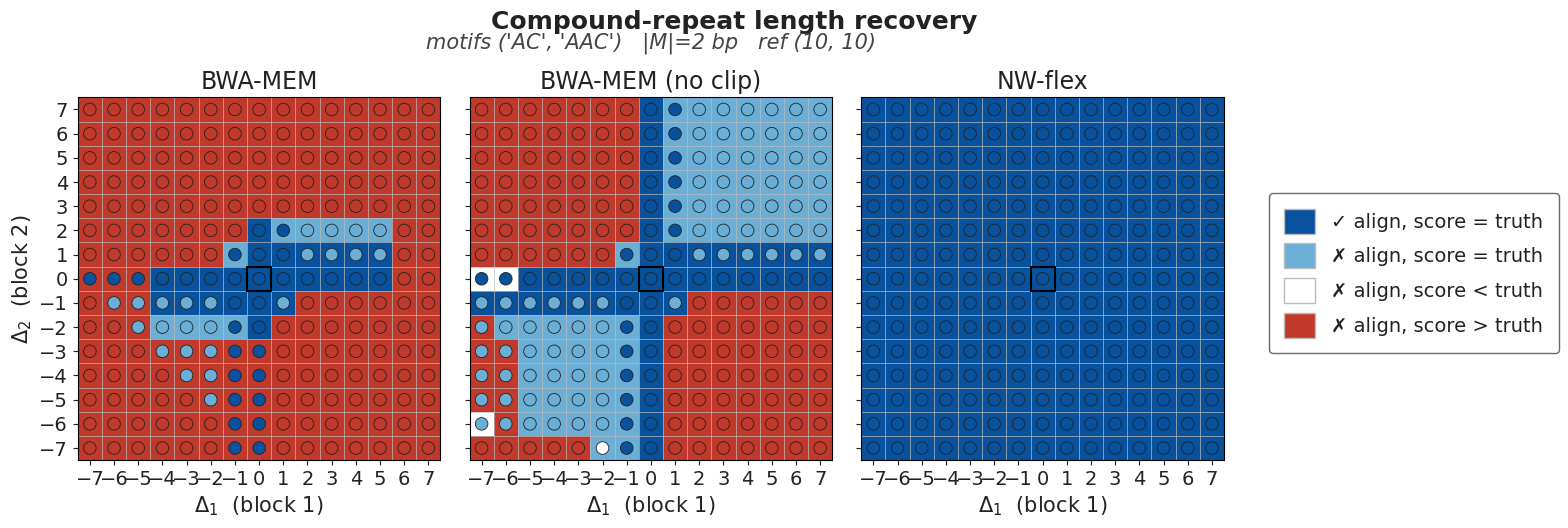

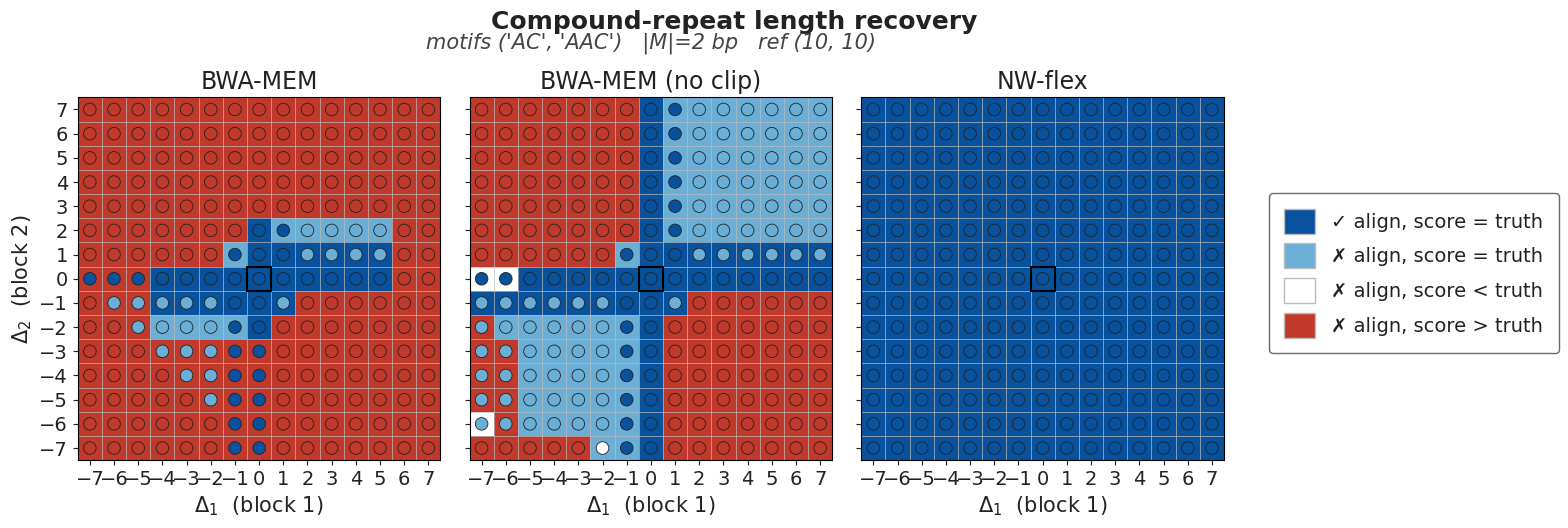

In [ ]:
# 2-D analogue of plot_correctness_heatmap. Aggregates each (Δ1, Δ2,
# arm) cell across reads using `combine_states` under the given policy
# (default "worst" so any failure in the cell is visible). Each cell
# carries the same fwd-Rectangle + rc-Circle convention as the NB7
# heatmap.
def _aggregate_states(states, policy):
    states = [s for s in states if isinstance(s, str)]
    if not states:
        return None
    return reduce(lambda a, b: combine_states(a, b, policy), states)


def _draw_2d_state_panel(ax, sub_df, *, deltas1, deltas2, color_of,
                         fontsize, combine_across_reads="worst"):
    has_per_strand = ("fwd_state" in sub_df.columns
                      and "rc_state" in sub_df.columns)
    for d1 in deltas1:
        for d2 in deltas2:
            cell = sub_df[(sub_df["delta1"] == d1) & (sub_df["delta2"] == d2)]
            if has_per_strand:
                fwd = _aggregate_states(cell["fwd_state"].tolist(),
                                        combine_across_reads)
                rc  = _aggregate_states(cell["rc_state"].tolist(),
                                        combine_across_reads)
            else:
                s = _aggregate_states(cell["state"].tolist(),
                                      combine_across_reads)
                fwd = rc = s
            ax.add_patch(Rectangle(
                (d1 - 0.5, d2 - 0.5), 1, 1,
                facecolor=color_of(fwd), edgecolor="none",
            ))
            ax.add_patch(Circle(
                (d1, d2), 0.26,
                facecolor=color_of(rc),
                edgecolor="#222222", linewidth=0.6, zorder=4,
            ))
    ax.set_xlim(deltas1[0] - 0.5, deltas1[-1] + 0.5)
    ax.set_ylim(deltas2[0] - 0.5, deltas2[-1] + 0.5)
    ax.set_aspect("equal")
    ax.set_xticks(deltas1)
    ax.set_yticks(deltas2)
    ax.set_xticks(np.array(deltas1, dtype=float) - 0.5, minor=True)
    ax.set_yticks(np.array(deltas2, dtype=float) - 0.5, minor=True)
    ax.grid(which="minor", color="#bbbbbb", linewidth=0.5)
    ax.tick_params(which="major", labelsize=fontsize, colors="#222222")
    ax.tick_params(which="minor", length=0)
    if 0 in deltas1 and 0 in deltas2:
        ax.add_patch(Rectangle(
            (-0.5, -0.5), 1, 1,
            fill=False, edgecolor="black", linewidth=1.5, zorder=5,
        ))


_STATE_COLORS_2D = dict(
    P="#08519c", T="#6baed6", M="#ffffff", D="#c0392b",
)


def _color_of_state(state, nan_color="#cccccc"):
    if isinstance(state, str) and state in _STATE_COLORS_2D:
        return _STATE_COLORS_2D[state]
    return nan_color


def _legend_handles_labels():
    handles = [
        Patch(facecolor=_STATE_COLORS_2D["P"], edgecolor="#bbbbbb"),
        Patch(facecolor=_STATE_COLORS_2D["T"], edgecolor="#bbbbbb"),
        Patch(facecolor=_STATE_COLORS_2D["M"], edgecolor="#bbbbbb"),
        Patch(facecolor=_STATE_COLORS_2D["D"], edgecolor="#bbbbbb"),
    ]
    labels = [
        "✓ align, score = truth",
        "✗ align, score = truth",
        "✗ align, score < truth",
        "✗ align, score > truth",
    ]
    return handles, labels


def plot_correctness_heatmap_2d(
    df, *, deltas1, deltas2, arm_titles,
    combine_across_reads="worst", fontsize=14,
    suptitle=None, subtitle=None,
):
    deltas1 = list(deltas1)
    deltas2 = list(deltas2)
    arms = list(arm_titles.keys())
    n = len(arms)
    label_size = fontsize + 1
    title_size = fontsize + 3

    fig, axes = plt.subplots(
        1, n, figsize=(5.0 * n + 2.5, 5.6), sharey=True,
        gridspec_kw={"wspace": 0.08},
        subplot_kw={"facecolor": "white"},
    )
    fig.patch.set_facecolor("white")
    if n == 1:
        axes = [axes]

    for ax, arm in zip(axes, arms):
        _draw_2d_state_panel(
            ax, df[df["arm"] == arm],
            deltas1=deltas1, deltas2=deltas2,
            color_of=_color_of_state, fontsize=fontsize,
            combine_across_reads=combine_across_reads,
        )
        ax.set_xlabel(r"$\Delta_1$  (block 1)",
                      fontsize=label_size, color="#222222")
        ax.set_title(arm_titles[arm], fontsize=title_size, color="#222222")
    axes[0].set_ylabel(r"$\Delta_2$  (block 2)",
                       fontsize=label_size, color="#222222")

    handles, labels = _legend_handles_labels()
    panel_top = 0.86 if suptitle else 0.92
    fig.subplots_adjust(right=0.78, top=panel_top, bottom=0.12)
    fig.legend(
        handles=handles, labels=labels, ncol=1,
        loc="center left", bbox_to_anchor=(0.80, 0.5),
        frameon=True, fontsize=fontsize, handlelength=1.6,
        handleheight=1.6, handletextpad=0.8, borderpad=0.8,
        facecolor="white", edgecolor="#444444", labelcolor="#222222",
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=title_size + 1, y=0.97,
                     fontweight="bold", color="#222222")
    if subtitle:
        sub_y = 0.93 if suptitle else 0.95
        cx = (axes[0].get_position().x0 + axes[-1].get_position().x1) / 2
        fig.text(cx, sub_y, subtitle, ha="center", va="top",
                 fontsize=label_size, style="italic", color="#444444")
    return fig


def plot_correctness_heatmap_2d_rows(
    df, *, deltas1, deltas2, row_values, row_col, arm_titles,
    row_label_fn=None, combine_across_reads="worst",
    fontsize=14, scale=0.8, suptitle=None, subtitle=None,
):
    deltas1 = list(deltas1)
    deltas2 = list(deltas2)
    arms = list(arm_titles.keys())
    row_values = list(row_values)
    n_rows = len(row_values)
    n_cols = len(arms)
    label_size = fontsize + 1
    title_size = fontsize + 3

    figsize = (
        scale * (5.0 * n_cols + 2.5),
        scale * (5.0 * n_rows + 1.6),
    )
    fig, axes = plt.subplots(
        n_rows, n_cols, figsize=figsize,
        sharex=True, sharey=True,
        gridspec_kw={"wspace": 0.04, "hspace": 0.20},
        subplot_kw={"facecolor": "white"},
        squeeze=False,
    )
    fig.patch.set_facecolor("white")

    for r, key in enumerate(row_values):
        sub_row = df[df[row_col] == key]
        for c, arm in enumerate(arms):
            ax = axes[r, c]
            _draw_2d_state_panel(
                ax, sub_row[sub_row["arm"] == arm],
                deltas1=deltas1, deltas2=deltas2,
                color_of=_color_of_state, fontsize=fontsize,
                combine_across_reads=combine_across_reads,
            )
            if r == 0:
                ax.set_title(arm_titles[arm], fontsize=title_size,
                             color="#222222")
            if r == n_rows - 1:
                ax.set_xlabel(r"$\Delta_1$",
                              fontsize=label_size, color="#222222")
        row_label = (row_label_fn(key) if row_label_fn is not None
                     else f"{row_col} = {key}")
        axes[r, 0].set_ylabel(
            f"{row_label}\n$\\Delta_2$",
            fontsize=label_size, color="#222222",
        )

    handles, labels = _legend_handles_labels()
    panel_top = 0.94 if suptitle else 0.96
    fig.subplots_adjust(right=0.82, top=panel_top, bottom=0.08)
    fig.legend(
        handles=handles, labels=labels, ncol=1,
        loc="center left", bbox_to_anchor=(0.84, 0.5),
        frameon=True, fontsize=fontsize, handlelength=1.6,
        handleheight=1.6, handletextpad=0.8, borderpad=0.8,
        facecolor="white", edgecolor="#444444", labelcolor="#222222",
    )
    if suptitle:
        fig.suptitle(suptitle, fontsize=title_size + 1, y=0.98,
                     fontweight="bold", color="#222222")
    if subtitle:
        sub_y = 0.95 if suptitle else 0.96
        cx = (axes[0, 0].get_position().x0
              + axes[0, -1].get_position().x1) / 2
        fig.text(cx, sub_y, subtitle, ha="center", va="top",
                 fontsize=label_size, style="italic", color="#444444")
    return fig


ARM_TITLES = {
    "BWA-std":     "BWA-MEM",
    "BWA-no-clip": "BWA-MEM (no clip)",
    "NW-flex":     "NW-flex",
}

plot_correctness_heatmap_2d(
    grid_df,
    deltas1=DELTAS1, deltas2=DELTAS2,
    arm_titles=ARM_TITLES,
    suptitle="Compound-repeat length recovery",
    subtitle=(f"motifs ({compound.R1!r}, {compound.R2!r})"
              f"   |M|={len(compound.M)} bp"
              f"   ref ({compound.N1}, {compound.N2})"),
)

### Bridge-length effect

Outer loop over $|M|$: rebuild the compound (and the rc frame, and the multi-block EP), rebuild the `methods` block bound to the new references, then re-run the same $(\Delta_1, \Delta_2)$ sweep. Each sweep's long-form output is tagged with its `bridge_len` and concatenated, so the stacked heatmap consumes exactly one pivoted DataFrame.

In [ ]:
# Match NB8: explicit (bridge_n1, bridge_n2) pairs yielding |M| ∈ {2,3,4,5}.
BRIDGE_PAIRS = [(1, 1), (2, 1), (2, 2), (3, 2)]
BRIDGE_LENGTHS = [n1 + n2 for n1, n2 in BRIDGE_PAIRS]

bridge_long_frames = []
for (n1, n2), m_len in zip(BRIDGE_PAIRS, BRIDGE_LENGTHS):
    cmp_m = build_compound_locus_from_panel(
        panel,
        motif1_len=2, motif2_len=3,
        ref_n1=10, ref_n2=10,
        bridge_n1=n1, bridge_n2=n2,
        flank_len=200,
    )
    rc_X_m, rc_X_ext_m, _, rc_zones_m, rc_zones_ext_m = (
        build_compound_mirror_frame(cmp_m, [])
    )
    ep_fwd_m = build_EP_multi_STR_phase(
        n=len(cmp_m.X_ext),
        blocks=[
            (cmp_m.zones_ext[0][0], cmp_m.zones_ext[0][1], cmp_m.k1),
            (cmp_m.zones_ext[1][0], cmp_m.zones_ext[1][1], cmp_m.k2),
        ],
    )
    ep_rc_m = build_EP_multi_STR_phase(
        n=len(rc_X_ext_m),
        blocks=[
            (rc_zones_ext_m[0][0], rc_zones_ext_m[0][1], cmp_m.k1),
            (rc_zones_ext_m[1][0], rc_zones_ext_m[1][1], cmp_m.k2),
        ],
    )
    methods_m = _build_compound_methods(
        cmp_m, rc_X_m, rc_X_ext_m, rc_zones_m, rc_zones_ext_m,
        ep_fwd_m, ep_rc_m,
    )
    variants_m = [_make_compound_variant(cmp_m, d1, d2)
                  for d1, d2 in product(DELTAS1, DELTAS2)]
    sub_long = sweep(variants_m,
                     _wrap_methods_for_compound(methods_m, variants_m))
    sub_long["bridge_len"] = m_len
    bridge_long_frames.append(sub_long)

bridge_long_df = pd.concat(bridge_long_frames, ignore_index=True)
bridge_df = pivot_for_heatmap(bridge_long_df, combine=COMBINE)

# Per-cell verdict counts (NB8-style), broken out by bridge length.
def _aggregate_per_cell_bridge(df):
    rows = []
    for (m_len, arm, d1, d2), g in df.groupby(
        ["bridge_len", "arm", "delta1", "delta2"],
    ):
        fwds = g["fwd_state"].dropna().tolist()
        rcs  = g["rc_state"].dropna().tolist()
        if not fwds or not rcs:
            continue
        f = reduce(lambda a, b: combine_states(a, b, "worst"), fwds)
        r = reduce(lambda a, b: combine_states(a, b, "worst"), rcs)
        rows.append({"bridge_len": m_len, "arm": arm,
                     "delta1": d1, "delta2": d2,
                     "fwd_state": f, "rc_state": r,
                     "state": combine_states(f, r, "best")})
    return pd.DataFrame(rows)

bridge_cell_df = _aggregate_per_cell_bridge(bridge_df)
print(f"Bridge sweep: {len(BRIDGE_LENGTHS)} bridge lengths x "
      f"{len(DELTAS1)} d1 x {len(DELTAS2)} d2 x {len(methods_m)} arms")
for m_len in BRIDGE_LENGTHS:
    sub = bridge_cell_df[bridge_cell_df["bridge_len"] == m_len]
    print(f"\n|M|={m_len} bp:")
    print(sub.groupby("arm")["state"].value_counts().unstack(fill_value=0)
          .reindex(columns=["P", "T", "M", "D"], fill_value=0).to_string())

Bridge sweep: 4 bridge lengths x 15 d1 x 15 d2 x 3 arms

|M|=2 bp:
state          P   T  M    D
arm                         
BWA-no-clip   57  67  0  101
BWA-std       40  16  0  169
NW-flex      225   0  0    0

|M|=3 bp:
state          P  T  M    D
arm                        
BWA-no-clip   58  1  0  166
BWA-std       40  1  0  184
NW-flex      225  0  0    0

|M|=4 bp:
state          P  T  M    D
arm                        
BWA-no-clip  180  1  0   44
BWA-std       90  1  0  134
NW-flex      225  0  0    0

|M|=5 bp:
state          P  T  M    D
arm                        
BWA-no-clip  202  1  0   22
BWA-std      106  0  0  119
NW-flex      225  0  0    0


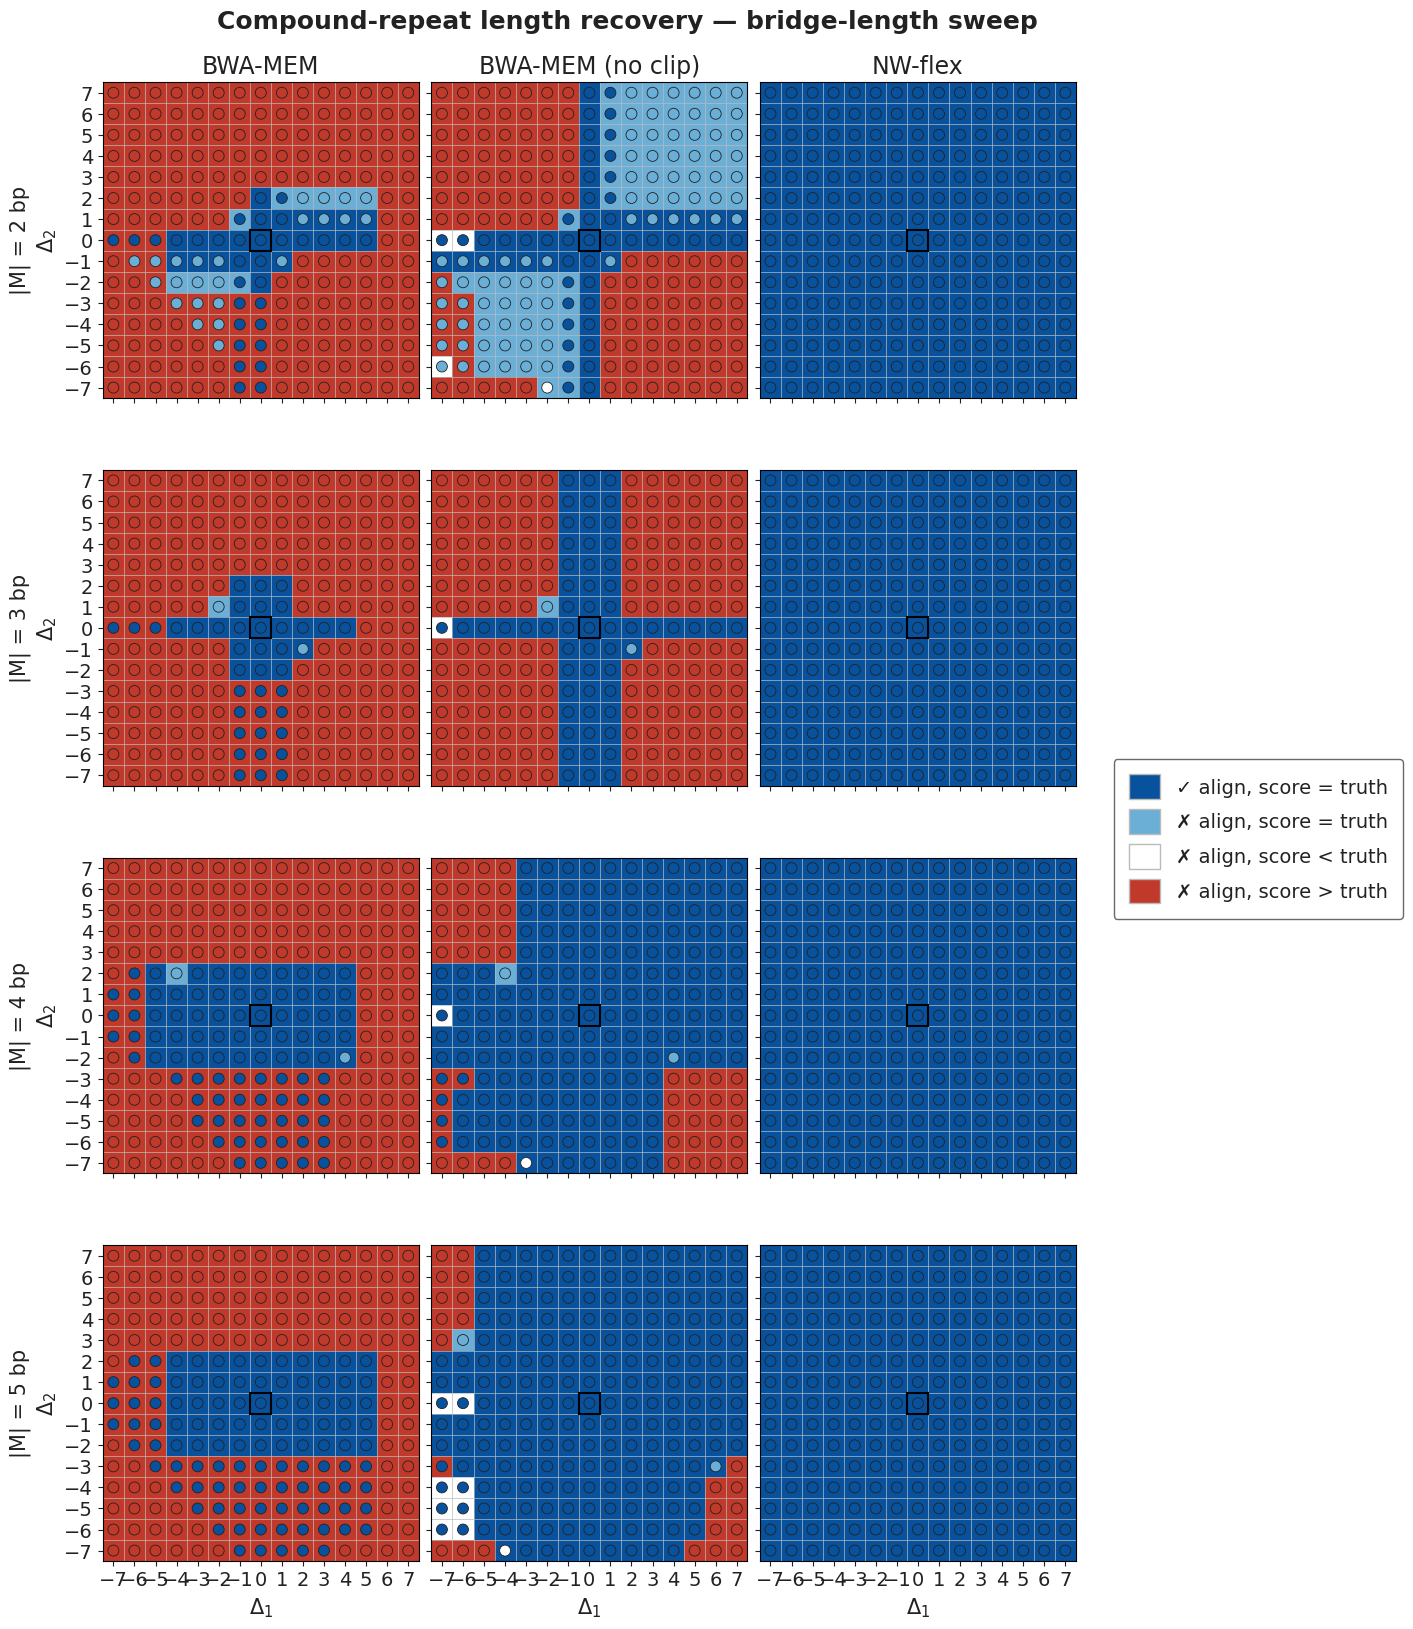

In [ ]:
plot_correctness_heatmap_2d_rows(
    bridge_df,
    deltas1=DELTAS1, deltas2=DELTAS2,
    row_values=BRIDGE_LENGTHS, row_col="bridge_len",
    arm_titles=ARM_TITLES,
    row_label_fn=lambda m: f"|M| = {m} bp",
    suptitle="Compound-repeat length recovery — bridge-length sweep",
);

## Summary

*(Placeholder — to be written once the sweeps are in.)*

- BWA's compound-repeat failure mode is a bridge-anchoring effect: short $|M|$ starves the seeder of anchor sequence between blocks; the per-block heuristic miss compounds across both boundaries.
- NW-flex is correct by construction on length-only compound sweeps: `build_EP_multi_STR_phase` is exhaustive over the product of allowed counts.
- The $|M|$ stack shows where BWA recovers (long bridge) versus where the compound story is visible (short bridge).